# Технологии нейросетевых вычислений



##ЛР2. Сверточные нейронные сети (10 баллов)

# О формате сдачи

🔷 **<font color='plum'>При решении используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Выводы подразумевают текстовый (письменный, не устный) ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

🔷 **<font color='plum'>Устная защита</font>**

    ❌❌❌ Если не пройдена устная защита по ЛР, то баллы не начисляются вовсе
    (вопросы устной защиты охватывают лекционный материал и практический материал по заданиям ЛР, список вопросов не публикуется)

# Задание

В этом задании вы поработаете с датасетом фотографий разных видов спорта, решите задачу многоклассовой классификации для достаточно большого вида классов, используете разные виды аугментации картинок и самостоятельно реализуете некую версию ResNet.

Хорошим тоном при написании моделей является фиксировать seed (некоторый параметр, от которого зависит результат работы рандомизированных алгоритмов), чтобы результаты обучения были воспроизводимы. Давайте и мы зафиксируем seed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/ITMO/TNC/shared

[Errno 2] No such file or directory: '/content/drive/MyDrive/ITMO/TNC/shared'
/content


In [ ]:
import PIL
import torchvision
from PIL import Image
from torchvision.transforms import v2
import pandas as pd
import numpy as np
import random
import torch
import os
from tqdm.auto import tqdm

def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed()

Random seed set as 42


Будем работать с датасетом фотографий разных видов спорта. Он уже за нас разделен train/test. Давайте скачаем его

In [ ]:
!pip install gdown > /dev/null
!gdown https://drive.google.com/uc?id=1biITy7cv0-lo-bwZrFkyDCGsEOWCBx5W
!unzip -n sports.zip > /dev/null

Downloading...
From (original): https://drive.google.com/uc?id=1biITy7cv0-lo-bwZrFkyDCGsEOWCBx5W
From (redirected): https://drive.google.com/uc?id=1biITy7cv0-lo-bwZrFkyDCGsEOWCBx5W&confirm=t&uuid=3de89286-ce30-4f71-8275-57cdcfd135d2
To: /content/sports.zip
100% 445M/445M [00:06<00:00, 71.4MB/s]


## <font color='DarkOrange'> **Задание 1 [1 балл]** </font>


Описание фотографий лежит в файле `sports.csv`. Давайте откроем файл в виде pandas датафрейма и посмотрим на примеры фото

In [ ]:
df = pd.read_csv('sports.csv')
df.head(10)

,class id,filepaths,labels,data set
0,0,train/air hockey/001.jpg,air hockey,train
1,0,train/air hockey/002.jpg,air hockey,train
2,0,train/air hockey/003.jpg,air hockey,train
3,0,train/air hockey/004.jpg,air hockey,train
4,0,train/air hockey/005.jpg,air hockey,train
5,0,train/air hockey/006.jpg,air hockey,train
6,0,train/air hockey/007.jpg,air hockey,train
7,0,train/air hockey/008.jpg,air hockey,train
8,0,train/air hockey/009.jpg,air hockey,train
9,0,train/air hockey/010.jpg,air hockey,train


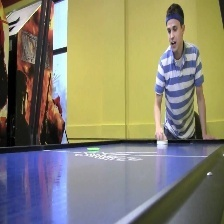

In [ ]:
img_example = Image.open(df['filepaths'][0])
img_example

Давайте посмотрим, сколько различных видов спорта есть в датасете, чтобы понять, на сколько классов будем обучать модель

In [ ]:
sport = pd.unique(df['labels'])
print(len(sport), sport)

100 ['air hockey' 'ampute football' 'archery' 'arm wrestling' 'axe throwing'
 'balance beam' 'barell racing' 'baseball' 'basketball' 'baton twirling'
 'bike polo' 'billiards' 'bmx' 'bobsled' 'bowling' 'boxing' 'bull riding'
 'bungee jumping' 'canoe slamon' 'cheerleading' 'chuckwagon racing'
 'cricket' 'croquet' 'curling' 'disc golf' 'fencing' 'field hockey'
 'figure skating men' 'figure skating pairs' 'figure skating women'
 'fly fishing' 'football' 'formula 1 racing' 'frisbee' 'gaga'
 'giant slalom' 'golf' 'hammer throw' 'hang gliding' 'harness racing'
 'high jump' 'hockey' 'horse jumping' 'horse racing' 'horseshoe pitching'
 'hurdles' 'hydroplane racing' 'ice climbing' 'ice yachting' 'jai alai'
 'javelin' 'jousting' 'judo' 'lacrosse' 'log rolling' 'luge'
 'motorcycle racing' 'mushing' 'nascar racing' 'olympic wrestling'
 'parallel bar' 'pole climbing' 'pole dancing' 'pole vault' 'polo'
 'pommel horse' 'rings' 'rock climbing' 'roller derby'
 'rollerblade racing' 'rowing' 'rugby' 'sail

Теперь выделим train/test части и сохраним картинки и таргет в виде списка, который будем потом передавать в даталоадер.

In [ ]:
train_df = df.loc[df['data set'] == 'train']
test_df = df.loc[df['data set'] == 'test']

Исходный датасет достаточно большой, и так как ресурсы колаба ограничены, давайте поработаем только с первыми 30 классами.


<font color='LightSteelBlue'>**Подсказка**</font> Все картинки одинакового размера, дополнительно это проверять не нужно

In [ ]:
# Сделайте заполнение по образцу, проходя по всем картинкам. Прогресс выводите с tqdm
train_images = [] # train_images.append((Image.open(path), class_id))
test_images = [] #  test_images.append((Image.open(path), class_id))


In [ ]:
# Первые 30 классов
selected_sports = sport[:30]

# Соответствие: название спорта -> номер класса
class_to_id = {
    class_name: class_id
    for class_id, class_name in enumerate(selected_sports)
}

# Оставляем только выбранные классы
train_df_30 = train_df[train_df["labels"].isin(selected_sports)]
test_df_30 = test_df[test_df["labels"].isin(selected_sports)]

for _, row in tqdm(
    train_df_30.iterrows(),
    total=len(train_df_30),
    desc="Loading train images"
):
    path = row["filepaths"]
    class_id = class_to_id[row["labels"]]

    # copy() загружает изображение в память и позволяет закрыть файл
    with Image.open(path) as image:
        image = image.convert("RGB").copy()

    train_images.append((image, class_id))


for _, row in tqdm(
    test_df_30.iterrows(),
    total=len(test_df_30),
    desc="Loading test images"
):
    path = row["filepaths"]
    class_id = class_to_id[row["labels"]]

    with Image.open(path) as image:
        image = image.convert("RGB").copy()

    test_images.append((image, class_id))

Loading train images:   0%|          | 0/4002 [00:00<?, ?it/s]

Loading test images:   0%|          | 0/150 [00:00<?, ?it/s]

Количество обучающих изображений: 4002
Количество тестовых изображений: 150
Количество классов: 30

Первые классы:
0 air hockey
1 ampute football
2 archery
3 arm wrestling
4 axe throwing

Размер изображения: (224, 224)
ID класса: 0


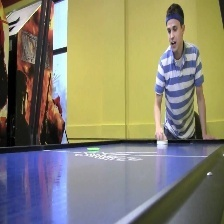


Размер изображения: (224, 224)
ID класса: 0


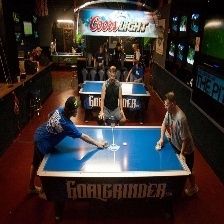


Размер изображения: (224, 224)
ID класса: 0


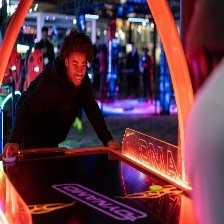


Размер изображения: (224, 224)
ID класса: 0


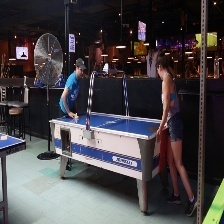


Размер изображения: (224, 224)
ID класса: 0


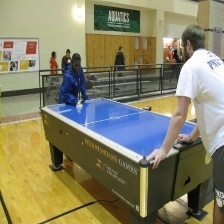


Размер изображения: (224, 224)
ID класса: 0


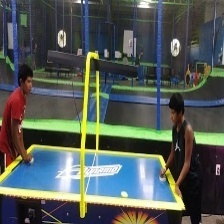


Размер изображения: (224, 224)
ID класса: 0


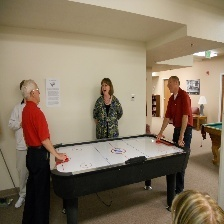


Размер изображения: (224, 224)
ID класса: 0


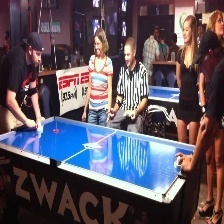


Размер изображения: (224, 224)
ID класса: 0


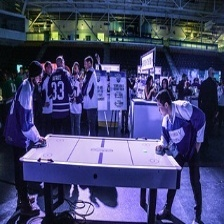


Размер изображения: (224, 224)
ID класса: 0


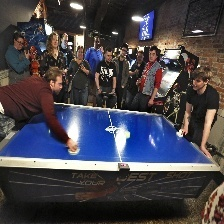


Размер изображения: (224, 224)
ID класса: 0


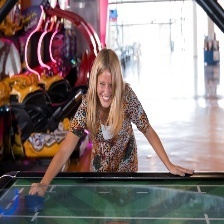


Размер изображения: (224, 224)
ID класса: 0


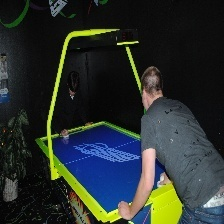


Размер изображения: (224, 224)
ID класса: 0


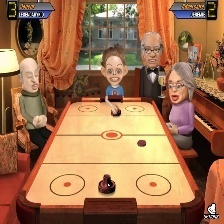


Размер изображения: (224, 224)
ID класса: 0


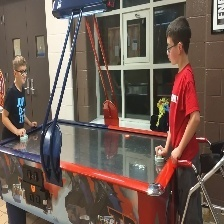


Размер изображения: (224, 224)
ID класса: 0


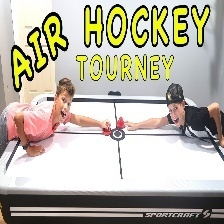


Размер изображения: (224, 224)
ID класса: 0


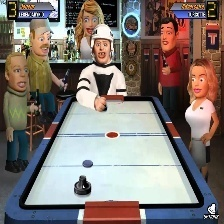


Размер изображения: (224, 224)
ID класса: 0


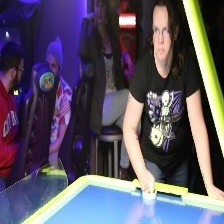


Размер изображения: (224, 224)
ID класса: 0


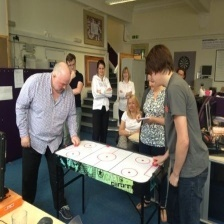


Размер изображения: (224, 224)
ID класса: 0


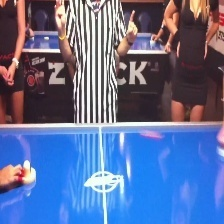


Размер изображения: (224, 224)
ID класса: 0


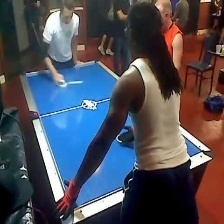


Размер изображения: (224, 224)
ID класса: 0


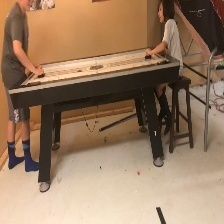


Размер изображения: (224, 224)
ID класса: 0


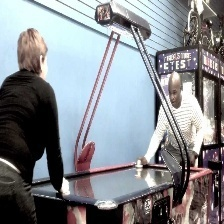


Размер изображения: (224, 224)
ID класса: 0


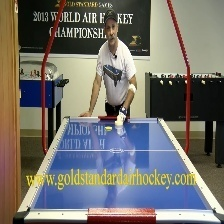


Размер изображения: (224, 224)
ID класса: 0


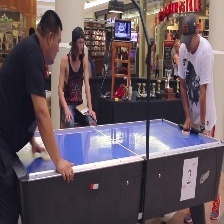


Размер изображения: (224, 224)
ID класса: 0


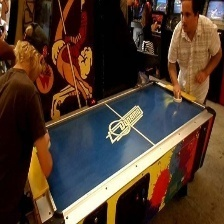


Размер изображения: (224, 224)
ID класса: 0


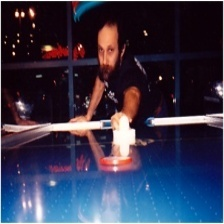


Размер изображения: (224, 224)
ID класса: 0


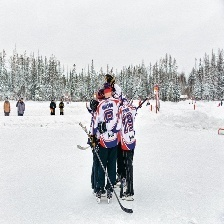


Размер изображения: (224, 224)
ID класса: 0


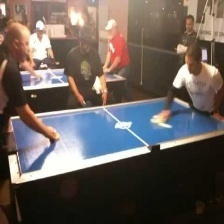


Размер изображения: (224, 224)
ID класса: 0


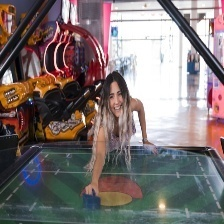


Размер изображения: (224, 224)
ID класса: 0


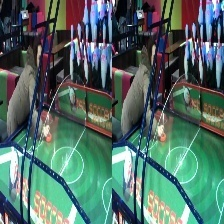


Размер изображения: (224, 224)
ID класса: 0


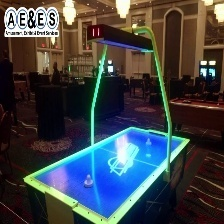


Размер изображения: (224, 224)
ID класса: 0


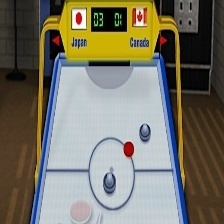


Размер изображения: (224, 224)
ID класса: 0


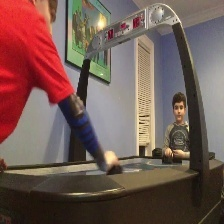


Размер изображения: (224, 224)
ID класса: 0


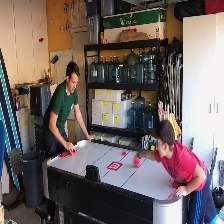


Размер изображения: (224, 224)
ID класса: 0


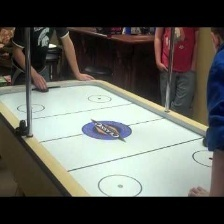


Размер изображения: (224, 224)
ID класса: 0


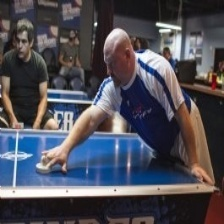


Размер изображения: (224, 224)
ID класса: 0


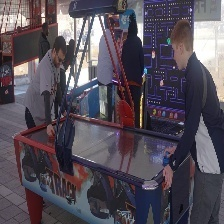


Размер изображения: (224, 224)
ID класса: 0


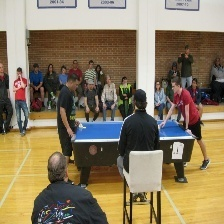


Размер изображения: (224, 224)
ID класса: 0


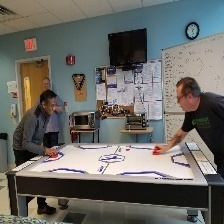


Размер изображения: (224, 224)
ID класса: 0


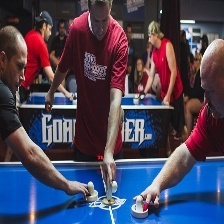


Размер изображения: (224, 224)
ID класса: 0


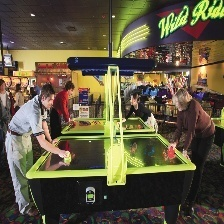


Размер изображения: (224, 224)
ID класса: 0


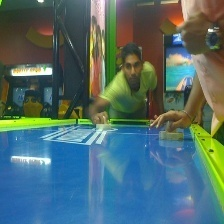


Размер изображения: (224, 224)
ID класса: 0


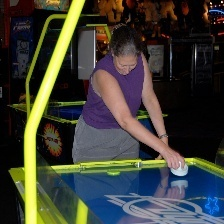


Размер изображения: (224, 224)
ID класса: 0


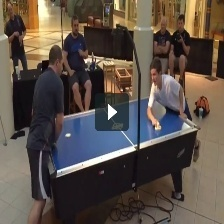


Размер изображения: (224, 224)
ID класса: 0


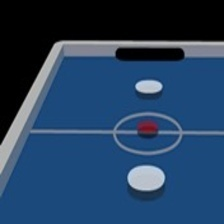


Размер изображения: (224, 224)
ID класса: 0


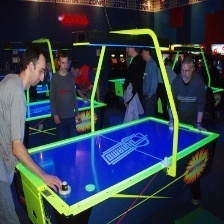


Размер изображения: (224, 224)
ID класса: 0


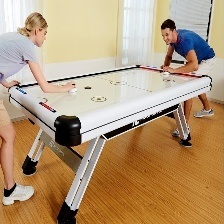


Размер изображения: (224, 224)
ID класса: 0


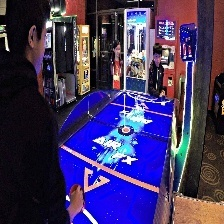


Размер изображения: (224, 224)
ID класса: 0


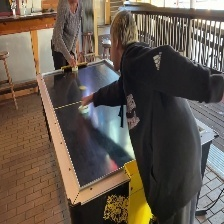


Размер изображения: (224, 224)
ID класса: 0


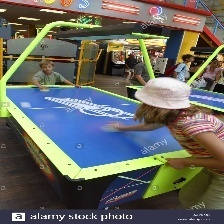


Размер изображения: (224, 224)
ID класса: 0


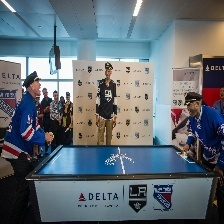


Размер изображения: (224, 224)
ID класса: 0


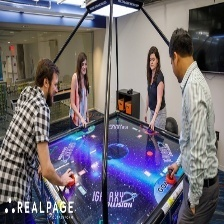


Размер изображения: (224, 224)
ID класса: 0


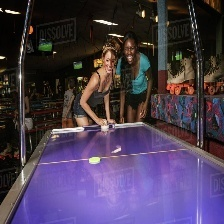


Размер изображения: (224, 224)
ID класса: 0


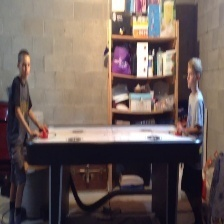


Размер изображения: (224, 224)
ID класса: 0


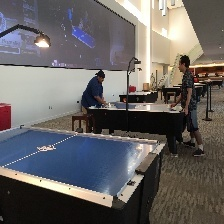


Размер изображения: (224, 224)
ID класса: 0


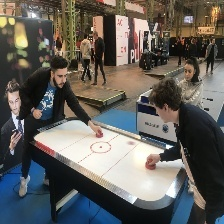


Размер изображения: (224, 224)
ID класса: 0


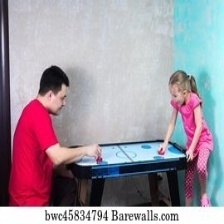


Размер изображения: (224, 224)
ID класса: 0


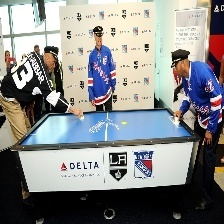


Размер изображения: (224, 224)
ID класса: 0


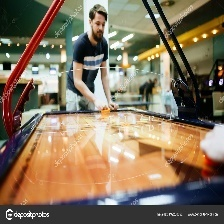


Размер изображения: (224, 224)
ID класса: 0


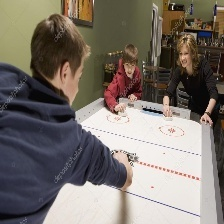


Размер изображения: (224, 224)
ID класса: 0


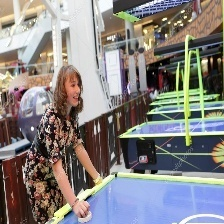


Размер изображения: (224, 224)
ID класса: 0


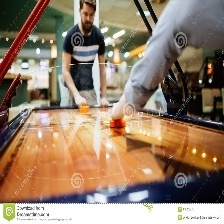


Размер изображения: (224, 224)
ID класса: 0


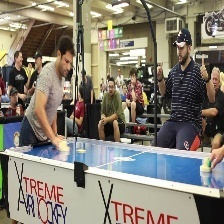


Размер изображения: (224, 224)
ID класса: 0


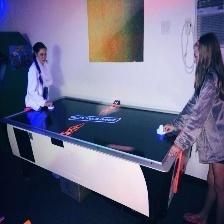


Размер изображения: (224, 224)
ID класса: 0


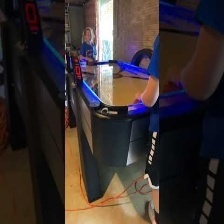


Размер изображения: (224, 224)
ID класса: 0


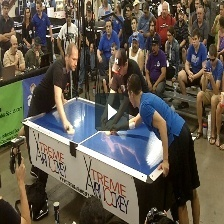


Размер изображения: (224, 224)
ID класса: 0


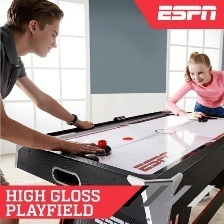


Размер изображения: (224, 224)
ID класса: 0


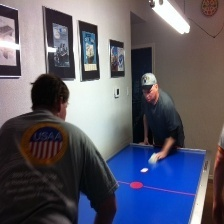


Размер изображения: (224, 224)
ID класса: 0


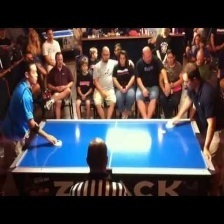


Размер изображения: (224, 224)
ID класса: 0


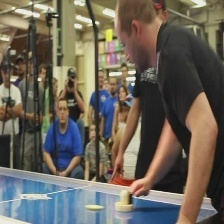


Размер изображения: (224, 224)
ID класса: 0


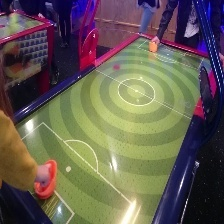


Размер изображения: (224, 224)
ID класса: 0


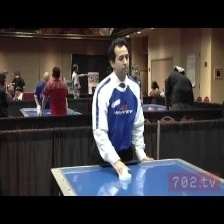


Размер изображения: (224, 224)
ID класса: 0


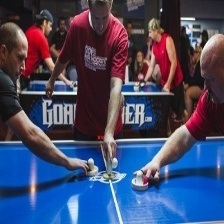


Размер изображения: (224, 224)
ID класса: 0


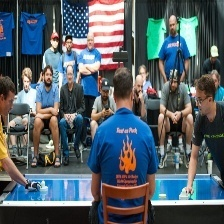


Размер изображения: (224, 224)
ID класса: 0


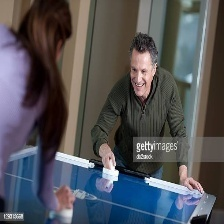


Размер изображения: (224, 224)
ID класса: 0


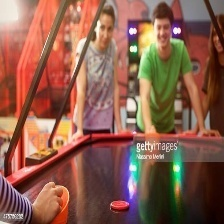


Размер изображения: (224, 224)
ID класса: 0


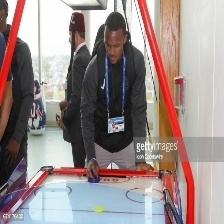


Размер изображения: (224, 224)
ID класса: 0


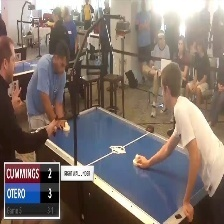


Размер изображения: (224, 224)
ID класса: 0


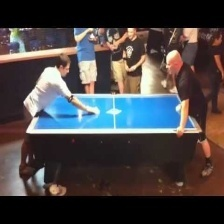


Размер изображения: (224, 224)
ID класса: 0


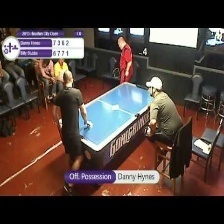


Размер изображения: (224, 224)
ID класса: 0


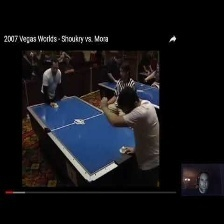


Размер изображения: (224, 224)
ID класса: 0


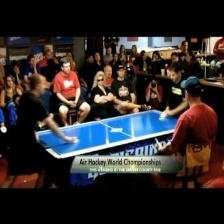


Размер изображения: (224, 224)
ID класса: 0


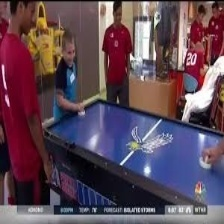


Размер изображения: (224, 224)
ID класса: 0


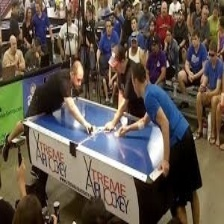


Размер изображения: (224, 224)
ID класса: 0


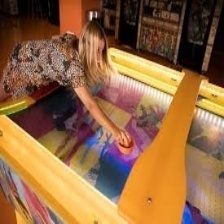


Размер изображения: (224, 224)
ID класса: 0


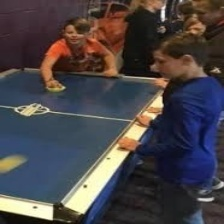


Размер изображения: (224, 224)
ID класса: 0


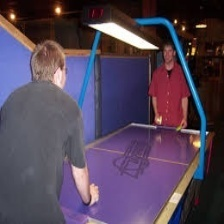


Размер изображения: (224, 224)
ID класса: 0


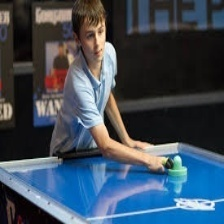


Размер изображения: (224, 224)
ID класса: 0


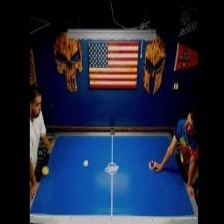


Размер изображения: (224, 224)
ID класса: 0


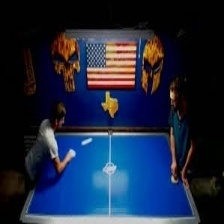


Размер изображения: (224, 224)
ID класса: 0


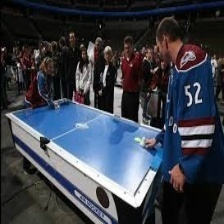


Размер изображения: (224, 224)
ID класса: 0


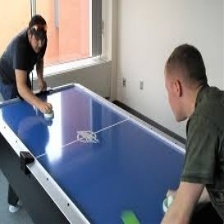


Размер изображения: (224, 224)
ID класса: 0


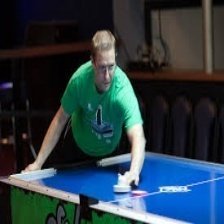


Размер изображения: (224, 224)
ID класса: 0


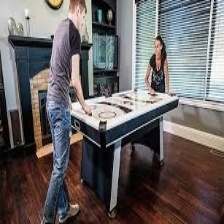


Размер изображения: (224, 224)
ID класса: 0


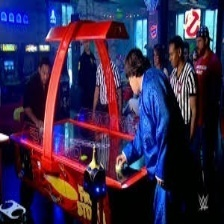


Размер изображения: (224, 224)
ID класса: 0


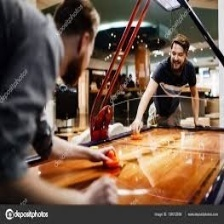


Размер изображения: (224, 224)
ID класса: 0


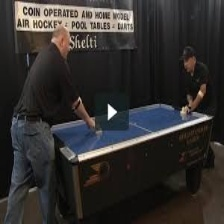


Размер изображения: (224, 224)
ID класса: 0


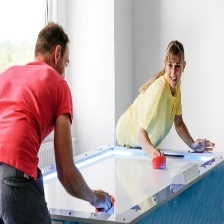


Размер изображения: (224, 224)
ID класса: 0


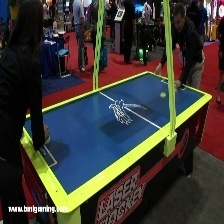


Размер изображения: (224, 224)
ID класса: 0


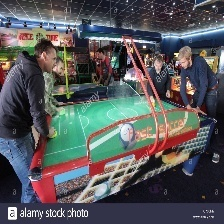

In [ ]:
print("Количество обучающих изображений:", len(train_images))
print("Количество тестовых изображений:", len(test_images))
print("Количество классов:", len(class_to_id))

print("\nПервые классы:")
for class_name, class_id in list(class_to_id.items())[:5]:
    print(class_id, class_name)
for i in range(100):
  image, target = train_images[i]
  print("\nРазмер изображения:", image.size)
  print("ID класса:", target)
  display(image)

## <font color='DarkOrange'> **Задание 2 [3 баллa]** </font>


В данном задании предлагаем вам самостоятельно изучить и воспользоваться различными видами аугментации, но обязательными будут: `RandomVerticalFlip`, `ElasticTransform`, `ChannelPermutation`.


<font color='LightSteelBlue'>**Подсказка**</font> Параметры у данных методов используйте те, которые вам кажутся логичными

<font color='MediumOrchid'>**Краткая теорсправка по методам:**</font> ???

In [ ]:
# Поэкспериментируйте с параметрами аугментации здесь

In [ ]:
from torchvision.transforms import v2
import torch
from torch.utils.data import Dataset, DataLoader


class SportDataset(Dataset):
    def __init__(self, source, is_train=True):
        self.is_train = is_train

        # Перевод PIL Image в тензор со значениями от 0 до 1
        self.basic_transform = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
        ])

        self.aug_transform = v2.Compose([
            # Дополнительные аугментации
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(degrees=10),

            # Обязательные аугментации
            # Вертикальный переворот для спортивных фото используем редко
            v2.RandomVerticalFlip(p=0.1),

            # Случайная эластичная деформация
            v2.RandomApply([
                v2.ElasticTransform(
                    alpha=20.0,
                    sigma=4.0
                )
            ], p=0.25),

            # Случайная перестановка RGB-каналов
            v2.RandomApply([
                v2.RandomChannelPermutation()
            ], p=0.15),

            # Небольшое изменение цвета и освещения
            v2.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.15,
                hue=0.05
            ),
        ])

        # Нормализация со статистиками ImageNet
        self.normalize = v2.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        data, target = list(zip(*source))

        # Один раз переводим все изображения в тензоры
        self.data = [
            self.basic_transform(image)
            for image in tqdm(data, desc="Converting images")
        ]

        self.target = torch.tensor(target, dtype=torch.long)

    def __getitem__(self, index):
        image = self.data[index]
        label = self.target[index]

        # Аугментации применяем только к обучающей выборке
        if self.is_train:
            image = self.aug_transform(image)

        # Нормализация нужна и для train, и для test
        image = self.normalize(image)

        return image, label

    def __len__(self):
        return len(self.data)

In [ ]:
dataset_train = SportDataset(
    train_images,
    is_train=True
)

dataset_test = SportDataset(
    test_images,
    is_train=False
)

dataloader_train = DataLoader(
    dataset=dataset_train,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

dataloader_test = DataLoader(
    dataset=dataset_test,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

Converting images:   0%|          | 0/4002 [00:00<?, ?it/s]

Converting images:   0%|          | 0/150 [00:00<?, ?it/s]

Здесь также приведем код, который может помочь при обучении нейросети

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def show_loss(iter_list, train_loss_list, test_loss_list, test_accuracy_list):
    clear_output(wait=True)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    ax[0].plot(iter_list[1:], train_loss_list[1:])
    ax[1].plot(iter_list, test_loss_list)
    ax[2].plot(iter_list, test_accuracy_list)

    ax[0].set_title('Train Loss')
    ax[1].set_title('Test Loss')
    ax[2].set_title('Test Accuracy')
    plt.show()

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def calc_accuracy(model, dataloader):
    y_pred = []
    y_test = []
    loss_sum = 0
    with torch.no_grad():
        for X, target in dataloader:
            X = X.cuda()
            target = target.cuda()
            logits = model(X)
            loss_sum += loss_fn(logits, target)
            y_pred.append(logits.argmax(dim=1))
            y_test.append(target)
        y_pred = torch.cat(y_pred)
        y_test = torch.cat(y_test)
    accuracy = torch.sum((y_pred == y_test)) / len(y_test)
    return accuracy.cpu(), loss_sum.item(), y_pred, y_test

In [ ]:
images, labels = next(iter(dataloader_train))

print("Размер батча изображений:", images.shape)
print("Размер батча меток:", labels.shape)
print("Тип изображений:", images.dtype)
print("Тип меток:", labels.dtype)
print("Минимум и максимум:", images.min().item(), images.max().item())

Размер батча изображений: torch.Size([64, 3, 224, 224])
Размер батча меток: torch.Size([64])
Тип изображений: torch.float32
Тип меток: torch.int64
Минимум и максимум: -2.1179039478302 2.640000104904175


In [ ]:
images, labels = next(iter(dataloader_train))

assert images.shape == (64, 3, 224, 224)
assert labels.shape == (64,)
assert images.dtype == torch.float32
assert labels.dtype == torch.int64

assert torch.isfinite(images).all()
assert labels.min() >= 0
assert labels.max() < 30

print("Все проверки пройдены!")
print("Классы в батче:", labels.unique().tolist())

Все проверки пройдены!
Классы в батче: [0, 1, 2, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29]


In [ ]:
train_image_1, _ = dataset_train[0]
train_image_2, _ = dataset_train[0]

test_image_1, _ = dataset_test[0]
test_image_2, _ = dataset_test[0]

print(
    "Train-изображения одинаковые:",
    torch.equal(train_image_1, train_image_2)
)

print(
    "Test-изображения одинаковые:",
    torch.equal(test_image_1, test_image_2)
)

Train-изображения одинаковые: False
Test-изображения одинаковые: True


## <font color='DarkOrange'> **Задание 3 [4 баллa]** </font>


Теперь вам предлагается реализовать архитектуру `ResNet18`

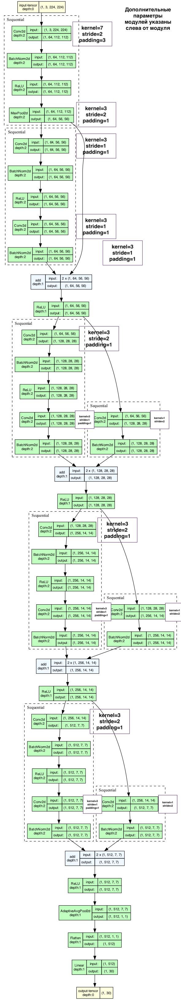

В случае, если по архитектуре выше будет неясно, какие параметры слоев, то еще один скриншот.


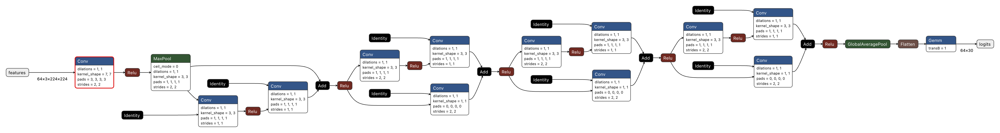

<font color='OrangeRed'>**Обратите внимание!**</font> Все сверточные слои обучаются с параметром `bias=False` (именно в таком варианте обычно применяют свертку, смещение зануляют)

Для блока `GlobalAveragePooling` используйте модуль `nn.AdaptiveAvgPool2d((1, 1))`

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn


class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        downsample=None
    ):
        super(ResidualBlock, self).__init__()

        # Основная ветвь
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Ветвь shortcut
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # Основная ветвь
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Меняем размер shortcut, если изменились
        # количество каналов или ширина/высота
        if self.downsample is not None:
            identity = self.downsample(x)

        # Остаточное соединение
        out = out + identity
        out = F.relu(out)

        return out

In [ ]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=100):
        super(ResNet18, self).__init__()

        # Вход: [B, 3, 224, 224]
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # [B, 64, 56, 56] -> [B, 64, 56, 56]
        self.layer1 = ResidualBlock(
            in_channels=64,
            out_channels=64,
            stride=1
        )

        # [B, 64, 56, 56] -> [B, 128, 28, 28]
        self.layer2 = ResidualBlock(
            in_channels=64,
            out_channels=128,
            stride=2,
            downsample=self._make_downsample(
                in_channels=64,
                out_channels=128,
                stride=2
            )
        )

        # [B, 128, 28, 28] -> [B, 256, 14, 14]
        self.layer3 = ResidualBlock(
            in_channels=128,
            out_channels=256,
            stride=2,
            downsample=self._make_downsample(
                in_channels=128,
                out_channels=256,
                stride=2
            )
        )

        # [B, 256, 14, 14] -> [B, 512, 7, 7]
        self.layer4 = ResidualBlock(
            in_channels=256,
            out_channels=512,
            stride=2,
            downsample=self._make_downsample(
                in_channels=256,
                out_channels=512,
                stride=2
            )
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    @staticmethod
    def _make_downsample(in_channels, out_channels, stride):
        return nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=stride,
                bias=False
            ),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        # [B, 3, 224, 224] -> [B, 64, 112, 112]
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        # -> [B, 64, 56, 56]
        out = self.maxpool(out)

        # Residual-блоки
        out = self.layer1(out)  # [B, 64, 56, 56]
        out = self.layer2(out)  # [B, 128, 28, 28]
        out = self.layer3(out)  # [B, 256, 14, 14]
        out = self.layer4(out)  # [B, 512, 7, 7]

        # Global Average Pooling
        out = self.avgpool(out)       # [B, 512, 1, 1]
        out = torch.flatten(out, 1)   # [B, 512]

        # Возвращаем логиты
        out = self.fc(out)            # [B, num_classes]

        return out

In [ ]:
model = ResNet18(num_classes=30)

In [ ]:
test_input = torch.randn(2, 3, 224, 224)

with torch.no_grad():
    test_output = model(test_input)

print("Вход:", test_input.shape)
print("Выход:", test_output.shape)

conv_layers = [
    module
    for module in model.modules()
    if isinstance(module, nn.Conv2d)
]

all_bias_disabled = all(
    layer.bias is None
    for layer in conv_layers
)

print("Количество сверточных слоев:", len(conv_layers))
print("У всех Conv2d bias=False:", all_bias_disabled)
print(
    "Количество обучаемых параметров:",
    sum(parameter.numel() for parameter in model.parameters())
)

Вход: torch.Size([2, 3, 224, 224])
Выход: torch.Size([2, 30])
Количество сверточных слоев: 12
У всех Conv2d bias=False: True
Количество обучаемых параметров: 4921182


## <font color='DarkOrange'> **Задание 4 [2 баллa]** </font>


Запустите процесс обучения и получите качество не менее 0.8 `Accuracy`

<font color='OrangeRed'>**Внимание!**</font> Перед запуском обучения на GPU убедитесь, что ваш код отрабатывает хотя бы несколько эпох на CPU. Только затем переходите на GPU!

<font color='OrangeRed'>**Внимание!**</font> Обучение уже может быть не мгновенным, поэтому при желании можете добавить в код обучения периодическое сохранение обученной модели. Модифицируйте код по мере обучения, если появляются инсайты

In [ ]:

from torch.optim import AdamW
from torch.optim.lr_scheduler import CyclicLR
from torch import nn

n_epoch = 1
model = ResNet18(num_classes=30).cuda()
loss_fn = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = CyclicLR(optimizer, base_lr=1e-4, max_lr=1e-2, step_size_up=1000, mode='triangular')

In [ ]:
def save_checkpoint(epoch, model, optimizer, loss, path="checkpoint.pth"):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(path="checkpoint.pth", model=None, optimizer=None):
    checkpoint = torch.load(path)

    if model:
        model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    return model, optimizer, epoch, loss

In [ ]:
dataset_train.aug_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.RandomVerticalFlip(p=0.05),

    v2.RandomApply([
        v2.ElasticTransform(alpha=15.0, sigma=4.0)
    ], p=0.10),

    v2.RandomApply([
        v2.RandomChannelPermutation()
    ], p=0.05),

    v2.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.03
    ),
])

In [ ]:
import os
import torch
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CyclicLR
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    max_batches=None
):
    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for batch_index, (images, labels) in enumerate(progress):
        if max_batches is not None and batch_index >= max_batches:
            break

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = loss_fn(logits, labels)

        loss.backward()

        # Защита от слишком больших градиентов
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        batch_size = images.size(0)

        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += batch_size

        progress.set_postfix(
            loss=f"{loss_sum / total:.4f}",
            accuracy=f"{correct / total:.4f}"
        )

    return loss_sum / total, correct / total

In [ ]:
@torch.no_grad()
def calc_accuracy(model, dataloader):
    model.eval()

    y_pred = []
    y_test = []

    loss_sum = 0.0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = loss_fn(logits, labels)

        batch_size = images.size(0)

        loss_sum += loss.item() * batch_size
        total += batch_size

        y_pred.append(logits.argmax(dim=1).cpu())
        y_test.append(labels.cpu())

    y_pred = torch.cat(y_pred)
    y_test = torch.cat(y_test)

    accuracy = (y_pred == y_test).float().mean()
    mean_loss = loss_sum / total

    return accuracy, mean_loss, y_pred, y_test

In [ ]:
def save_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    loss,
    accuracy,
    path="checkpoint.pth"
):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "loss": loss,
        "accuracy": accuracy,
    }, path)


def load_checkpoint(
    path,
    model,
    optimizer=None,
    scheduler=None,
    device="cpu"
):
    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

    if scheduler is not None:
        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

    return (
        model,
        optimizer,
        scheduler,
        checkpoint["epoch"],
        checkpoint["loss"],
        checkpoint["accuracy"]
    )

In [ ]:
cpu_device = torch.device("cpu")

cpu_model = ResNet18(num_classes=30).to(cpu_device)

cpu_loss_fn = nn.CrossEntropyLoss()

cpu_optimizer = AdamW(
    cpu_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

for epoch in range(2):
    cpu_loss, cpu_accuracy = train_one_epoch(
        model=cpu_model,
        dataloader=dataloader_train,
        optimizer=cpu_optimizer,
        loss_fn=cpu_loss_fn,
        device=cpu_device,
        scheduler=None,
        max_batches=5
    )

    print(
        f"CPU check {epoch + 1}/2 | "
        f"loss={cpu_loss:.4f} | "
        f"accuracy={cpu_accuracy:.4f}"
    )

del cpu_model
del cpu_optimizer

Training:   0%|          | 0/63 [00:00<?, ?it/s]

CPU check 1/2 | loss=3.4638 | accuracy=0.0813


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

CPU check 2/2 | loss=2.9553 | accuracy=0.1594


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Используемое устройство:", device)

set_seed(42)

n_epochs = 40
target_accuracy = 0.82

model = ResNet18(num_classes=30).to(device)

loss_fn = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer = AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

scheduler = CyclicLR(
    optimizer,
    base_lr=1e-4,
    max_lr=1e-3,
    step_size_up=2 * len(dataloader_train),
    mode="triangular2",
    cycle_momentum=False
)

Используемое устройство: cuda
Random seed set as 42


In [ ]:
best_accuracy = 0.0

epoch_list = []
train_loss_list = []
test_loss_list = []
test_accuracy_list = []

for epoch in range(n_epochs):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=dataloader_train,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        scheduler=scheduler
    )

    test_accuracy, test_loss, _, _ = calc_accuracy(
        model,
        dataloader_test
    )

    test_accuracy_value = test_accuracy.item()

    epoch_list.append(epoch + 1)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    test_accuracy_list.append(test_accuracy_value)

    print(
        f"Epoch {epoch + 1:02d}/{n_epochs} | "
        f"train loss={train_loss:.4f} | "
        f"train accuracy={train_accuracy:.4f} | "
        f"test loss={test_loss:.4f} | "
        f"test accuracy={test_accuracy_value:.4f} | "
        f"lr={get_lr(optimizer):.6f}"
    )

    # Сохраняем лучшую модель
    if test_accuracy_value > best_accuracy:
        best_accuracy = test_accuracy_value

        save_checkpoint(
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            loss=test_loss,
            accuracy=best_accuracy,
            path="best_resnet18.pth"
        )

        print(
            f"Сохранена лучшая модель: "
            f"accuracy={best_accuracy:.4f}"
        )

    # Дополнительное периодическое сохранение
    if (epoch + 1) % 5 == 0:
        save_checkpoint(
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            loss=test_loss,
            accuracy=test_accuracy_value,
            path="last_checkpoint.pth"
        )

    # Останавливаемся с небольшим запасом выше 0.8
    if best_accuracy >= target_accuracy:
        print("Целевая точность достигнута!")
        break

Training:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 01/40 | train loss=2.6993 | train accuracy=0.2531 | test loss=2.2141 | test accuracy=0.3733 | lr=0.000550
Сохранена лучшая модель: accuracy=0.3733


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


Epoch 11/40 | train loss=1.2959 | train accuracy=0.7009 | test loss=1.1239 | test accuracy=0.7667 | lr=0.000213


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 12/40 | train loss=1.1495 | train accuracy=0.7509 | test loss=1.0236 | test accuracy=0.8533 | lr=0.000100
Сохранена лучшая модель: accuracy=0.8533
Целевая точность достигнута!


In [ ]:
model, _, _, best_epoch, _, saved_accuracy = load_checkpoint(
    path="best_resnet18.pth",
    model=model,
    device=device
)

accuracy, test_loss, y_pred, y_test = calc_accuracy(
    model,
    dataloader_test
)

print("Лучшая эпоха:", best_epoch + 1)
print("Test loss:", test_loss)
print("Test accuracy:", accuracy.item())

assert accuracy.item() > 0.8, (
    f"Accuracy пока равна {accuracy.item():.4f}"
)

print("Отлично!")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782cbaa6ad40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Лучшая эпоха: 12
Test loss: 1.02358877658844
Test accuracy: 0.8533333539962769
Отлично!
